# Segmentación Semántica de Grietas en Video con UNET++

Este notebook implementa el pipeline optimizado de inferencia en video para la segmentación de grietas utilizando la arquitectura **PIDNet** (*Proportional-Integral-Derivative Network*, CVPR 2023).

### Características Principales:
- **100% Compatible con Google Colab y Entorno Local**: Montaje automático de Drive y resolución robusta de rutas.
- **Configuración Centralizada**: Rutas y parámetros editables al inicio del notebook.
- **Preservación de Aspect Ratio**: Escala adaptativa a múltiplos de 32 (requerimiento de PIDNet) sin distorsionar videos 16:9.
- **Inferencia de Alto Rendimiento**: Batching de frames configurable, aceleración por hardware con `torch.inference_mode()` y *Automatic Mixed Precision* (AMP FP16).
- **Superposición Vectorizada y Telemetría HUD**: Overlay de máscara semitransparente con contornos de alta visibilidad (`cv2.drawContours`) y telemetría en tiempo real (FPS, estado y porcentaje de área de grieta).
- **Reporte Estadístico y Timeline de Daño**: Gráfico de la evolución del área de grieta a lo largo del tiempo, visualización de keyframes y reproductor HTML5 integrado en Colab.


In [1]:
# ==== Solo para ejecutar en Colab / Local ========
try:
    from google.colab import drive
    import os
    import sys

    # 1. Montar Google Drive
    drive.mount('/content/drive')

    # 2. Definir la ruta a tu proyecto dentro de Drive
    # (Asegúrate de ajustar esta ruta si guardaste la carpeta en otro lado dentro de tu Drive)
    project_path = '/content/drive/MyDrive/tp_computer_vision_ii'
    notebook_dir = os.path.join(project_path, 'src', 'unet')

    # 3. Movernos al directorio donde está el notebook para que las rutas relativas funcionen
    os.chdir(notebook_dir)

    # 4. Agregar la ruta a sys.path para que Python encuentre la carpeta "models"
    if notebook_dir not in sys.path:
        sys.path.append(notebook_dir)

    print("Directorio actual:", os.getcwd())
    IN_COLAB = True

except:
    IN_COLAB = False
    import os, sys
    current_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in locals() else os.getcwd()
    if current_dir not in sys.path:
        sys.path.append(current_dir)
    print("Ejecutando en entorno Local. Directorio actual:", os.getcwd())


Mounted at /content/drive
Directorio actual: /content/drive/MyDrive/tp_computer_vision_ii/src/unet


In [2]:
# ==============================================================================
# 1. PARÁMETROS Y RUTAS CONFIGURABLES DE ENTRADA / SALIDA
# ==============================================================================

# ─── Rutas de Archivos (Compatibles con Colab y Local) ────────────────────────
# Checkpoint del modelo entrenado
CHECKPOINT_PATH = "best_unet_unet++resnet34_5layers_scse.pth"
VIDEO_INPUT_PATH = "../../datasets/videos/crack_vids.mp4"
VIDEO_OUTPUT_PATH = "../../datasets/videos/crack_vids_unetpp_resnet34_scse.mp4"

TARGET_HEIGHT = 512
TARGET_WIDTH = 512
PROB_THRESHOLD = 0.5

BATCH_SIZE = 1
MAX_FRAMES = None
USE_AMP = True

MODEL_LABEL = "UNet++ ResNet34 D5 SCSE"
SHOW_HUD = True
OVERLAY_ALPHA = 0.45
MASK_COLOR_BGR = (0, 0, 255)
DRAW_CONTOURS = True
CONTOUR_COLOR_BGR = (0, 255, 255)


In [4]:
# ==============================================================================
# 2. CONFIGURACIÓN DE DEPENDENCIAS, DISPOSITIVO Y RUTAS
# ==============================================================================
%pip install -q segmentation-models-pytorch

import os
import sys
import time
from pathlib import Path
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import segmentation_models_pytorch as smp

# Selección de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de cómputo: {device}")
if device.type == 'cuda':
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

def resolve_path(path_str):
    """
    Resuelve rutas de forma robusta y cross-platform tanto en Colab como en Local,
    soportando referencias relativas al directorio actual o a la raíz del proyecto.
    """
    clean_p = path_str.replace('\\', '/')
    p = Path(clean_p)
    if p.exists():
        return str(p)

    # Búsqueda en rutas relativas comunes
    search_roots = ['.', '..', '../..', 'src/unet', 'tp_computer_vision_ii']
    for root in search_roots:
        candidate = Path(root) / clean_p
        if candidate.exists():
            return str(candidate.resolve())
    return str(p)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00
Dispositivo de cómputo: cuda
GPU detectada: Tesla T4


In [5]:
# ==============================================================================
# 3. CARGA DEL MODELO PIDNET Y WARM-UP
# ==============================================================================
def load_unetpp_model(checkpoint_path, device):
    ckpt_resolved = resolve_path(checkpoint_path)
    if not os.path.exists(ckpt_resolved): raise FileNotFoundError(f"No se encontró el checkpoint: {ckpt_resolved}")

    model = smp.UnetPlusPlus(
        encoder_name="resnet34",
        encoder_depth=5,
        encoder_weights=None,
        decoder_channels=(512, 256, 128, 64, 32),
        decoder_use_norm="batchnorm",
        decoder_attention_type="scse",
        in_channels=3,
        classes=1,
        activation=None
    )

    ckpt = torch.load(ckpt_resolved, map_location="cpu")
    state = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=True)
    model.to(device).eval()

    if device.type == "cuda":
        with torch.inference_mode(): model(torch.randn(1, 3, TARGET_HEIGHT, TARGET_WIDTH, device=device))
        torch.cuda.synchronize()

    threshold = ckpt.get("threshold", PROB_THRESHOLD) if isinstance(ckpt, dict) else PROB_THRESHOLD
    return model, threshold

model, PROB_THRESHOLD = load_unetpp_model(CHECKPOINT_PATH, device)


In [6]:
# ==============================================================================
# 4. FUNCIONES DE PROCESAMIENTO VECTORIZADO Y OVERLAY
# ==============================================================================

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

mean_tensor = torch.tensor(IMAGENET_MEAN, device=device, dtype=torch.float32).view(1, 3, 1, 1)
std_tensor = torch.tensor(IMAGENET_STD, device=device, dtype=torch.float32).view(1, 3, 1, 1)

def preprocess_batch(frames_bgr_list, target_size, device):
    """
    Convierte una lista de frames BGR (numpy uint8) a un tensor normalizado ImageNet [B, 3, H, W] en GPU.
    """
    target_h, target_w = target_size
    resized_frames = [
        cv2.cvtColor(cv2.resize(f, (target_w, target_h), interpolation=cv2.INTER_LINEAR), cv2.COLOR_BGR2RGB)
        for f in frames_bgr_list
    ]
    batch_np = np.stack(resized_frames, axis=0)
    batch_tensor = torch.from_numpy(batch_np).permute(0, 3, 1, 2).float().to(device, non_blocking=True) / 255.0
    batch_tensor = (batch_tensor - mean_tensor) / std_tensor
    return batch_tensor

def apply_crack_overlay(frame_bgr, mask_binary, alpha=0.45, mask_color_bgr=(0, 0, 255),
                        draw_contours=True, contour_color_bgr=(0, 255, 255), hud_lines=None):
    """
    Superpone la máscara de segmentación y contornos sobre el frame original de forma vectorizada y rápida.
    """
    out_frame = frame_bgr.copy()
    if np.any(mask_binary):
        mask_bool = mask_binary.astype(bool)
        color_layer = np.full_like(frame_bgr, mask_color_bgr, dtype=np.uint8)

        # Blending vectorizado sobre píxeles de grieta
        out_frame[mask_bool] = cv2.addWeighted(
            frame_bgr[mask_bool], 1.0 - alpha,
            color_layer[mask_bool], alpha, 0
        )

        # Contornos perimetrales nítidos
        if draw_contours:
            contours, _ = cv2.findContours(mask_binary.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(out_frame, contours, -1, contour_color_bgr, 1, cv2.LINE_AA)

    # Panel HUD de telemetría
    if hud_lines:
        box_w = 340
        box_h = 16 + len(hud_lines) * 26
        cv2.rectangle(out_frame, (10, 10), (10 + box_w, 10 + box_h), (20, 20, 20), -1)
        cv2.rectangle(out_frame, (10, 10), (10 + box_w, 10 + box_h), (200, 200, 200), 1)
        for i, line in enumerate(hud_lines):
            y_pos = 32 + i * 26
            cv2.putText(out_frame, line, (20, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (255, 255, 255), 1, cv2.LINE_AA)

    return out_frame


In [7]:
# ==============================================================================
# 5. MOTOR DE INFERENCIA EN VIDEO POR LOTES (BATCH INFERENCE ENGINE)
# ==============================================================================

video_in_resolved = resolve_path(VIDEO_INPUT_PATH)
video_out_resolved = resolve_path(VIDEO_OUTPUT_PATH)

if not os.path.exists(video_in_resolved):
    raise FileNotFoundError(f"No se encontró el video de entrada en: {video_in_resolved}")

out_dir = os.path.dirname(os.path.abspath(video_out_resolved))
if out_dir:
    os.makedirs(out_dir, exist_ok=True)

# Abrir video de entrada
cap = cv2.VideoCapture(video_in_resolved)
if not cap.isOpened():
    raise IOError(f"No se pudo abrir el archivo de video: {video_in_resolved}")

fps_in = cap.get(cv2.CAP_PROP_FPS)
if fps_in <= 0 or np.isnan(fps_in):
    fps_in = 25.0
orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if MAX_FRAMES is not None and MAX_FRAMES > 0:
    total_frames = min(total_frames, MAX_FRAMES)

# Calcular dimensiones de procesamiento preservando aspect ratio
target_h, target_w = TARGET_HEIGHT, TARGET_WIDTH

# Configurar VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(video_out_resolved, fourcc, fps_in, (orig_w, orig_h))

print(f"Resolución original: {orig_w}x{orig_h} @ {fps_in:.2f} FPS")
print(f"Resolución UNET++:   {target_w}x{target_h} (múltiplo de 32)")
print(f"Frames a procesar:   {total_frames} | Tamaño de Batch: {BATCH_SIZE} | AMP: {USE_AMP}")

# Estructuras para recolección de estadísticas
timeline_stats = {
    'frame_idx': [],
    'time_sec': [],
    'crack_area_pct': [],
    'has_crack': [],
    'batch_infer_time': []
}

frame_count = 0
total_infer_time = 0.0
total_post_time = 0.0
t_start_pipeline = time.perf_counter()

use_amp_cuda = (USE_AMP and device.type == 'cuda')

pbar = tqdm(total=total_frames, desc="Segmentando Video", unit="frame")

while frame_count < total_frames:
    # 1. Leer lote de frames
    batch_frames = []
    while len(batch_frames) < BATCH_SIZE and (frame_count + len(batch_frames)) < total_frames:
        ret, frame = cap.read()
        if not ret:
            break
        batch_frames.append(frame)

    if not batch_frames:
        break

    cur_batch_size = len(batch_frames)

    # 2. Preprocesamiento en lote
    t_pre = time.perf_counter()
    batch_tensor = preprocess_batch(batch_frames, (target_h, target_w), device)

    # 3. Inferencia de la Red
    t_inf_start = time.perf_counter()
    with torch.inference_mode():
        with torch.amp.autocast('cuda', enabled=use_amp_cuda):
            logits = model(batch_tensor)
            logits = F.interpolate(logits, size=(orig_h, orig_w), mode="bilinear", align_corners=False)
            probs = torch.sigmoid(logits[:, 0])
            masks_batch = (probs >= PROB_THRESHOLD).cpu().numpy().astype(np.uint8)


    if device.type == 'cuda':
        torch.cuda.synchronize()
    t_inf_end = time.perf_counter()
    batch_inf_time = t_inf_end - t_inf_start
    total_infer_time += batch_inf_time

    # 4. Postprocesamiento, Overlay y Escritura
    t_post_start = time.perf_counter()
    for b_idx in range(cur_batch_size):
        curr_frame_idx = frame_count + b_idx
        mask_pred = masks_batch[b_idx]
        frame_orig = batch_frames[b_idx]

        crack_pixels = int(mask_pred.sum())
        total_pixels = orig_h * orig_w
        crack_pct = (crack_pixels / total_pixels) * 100.0
        has_crack = crack_pct > 0.01

        # Telemetría HUD
        instant_fps = cur_batch_size / max(1e-5, batch_inf_time)
        hud_lines = None
        if SHOW_HUD:
            hud_lines = [
                f"{MODEL_LABEL} | Frame: {curr_frame_idx + 1}/{total_frames}",
                f"FPS Inferencia: {instant_fps:.1f}",
                f"Grieta: {'DETECTADA' if has_crack else 'NO DETECTADA'}",
                f"Severidad Area: {crack_pct:.2f}%"
            ]
            

        frame_annotated = apply_crack_overlay(
            frame_orig, mask_pred,
            alpha=OVERLAY_ALPHA,
            mask_color_bgr=MASK_COLOR_BGR,
            draw_contours=DRAW_CONTOURS,
            contour_color_bgr=CONTOUR_COLOR_BGR,
            hud_lines=hud_lines
        )
        writer.write(frame_annotated)

        # Registro de métricas
        timeline_stats['frame_idx'].append(curr_frame_idx)
        timeline_stats['time_sec'].append(curr_frame_idx / fps_in)
        timeline_stats['crack_area_pct'].append(crack_pct)
        timeline_stats['has_crack'].append(has_crack)

    t_post_end = time.perf_counter()
    total_post_time += (t_post_end - t_post_start)

    frame_count += cur_batch_size
    pbar.update(cur_batch_size)

pbar.close()
cap.release()
writer.release()

t_end_pipeline = time.perf_counter()
total_pipeline_time = t_end_pipeline - t_start_pipeline

avg_pipeline_fps = frame_count / total_pipeline_time if total_pipeline_time > 0 else 0
avg_infer_fps = frame_count / total_infer_time if total_infer_time > 0 else 0

print("\n" + "="*60)
print("              RESUMEN DE PROCESAMIENTO DE VIDEO             ")
print("="*60)
print(f" Video de entrada           : {video_in_resolved}")
print(f" Video de salida            : {video_out_resolved}")
print(f" Frames totales procesados  : {frame_count}")
print(f" Tiempo total pipeline      : {total_pipeline_time:.2f} s")
print(f" Tiempo neto inferencia GPU : {total_infer_time:.2f} s")
print(f" FPS Pipeline completo      : {avg_pipeline_fps:.2f} FPS")
print(f" FPS Inferencia neta (Red)  : {avg_infer_fps:.2f} FPS")
print("="*60)


Resolución original: 3840x2160 @ 60.00 FPS
Resolución UNET++:   512x512 (múltiplo de 32)
Frames a procesar:   7358 | Tamaño de Batch: 1 | AMP: True


Segmentando Video:   0%|          | 0/7358 [00:00<?, ?frame/s]


              RESUMEN DE PROCESAMIENTO DE VIDEO             
 Video de entrada           : ../../datasets/videos/crack_vids.mp4
 Video de salida            : ../../datasets/videos/crack_vids_unetpp_resnet34_scse.mp4
 Frames totales procesados  : 7358
 Tiempo total pipeline      : 2384.23 s
 Tiempo neto inferencia GPU : 527.31 s
 FPS Pipeline completo      : 3.09 FPS
 FPS Inferencia neta (Red)  : 13.95 FPS


--- Estadísticas de Defectos en el Video ---
Frames con grieta detectada : 7343/7358 (99.8%)
Porcentaje de área promedio : 3.861%
Porcentaje de área máximo   : 28.691% (Frame #3685)


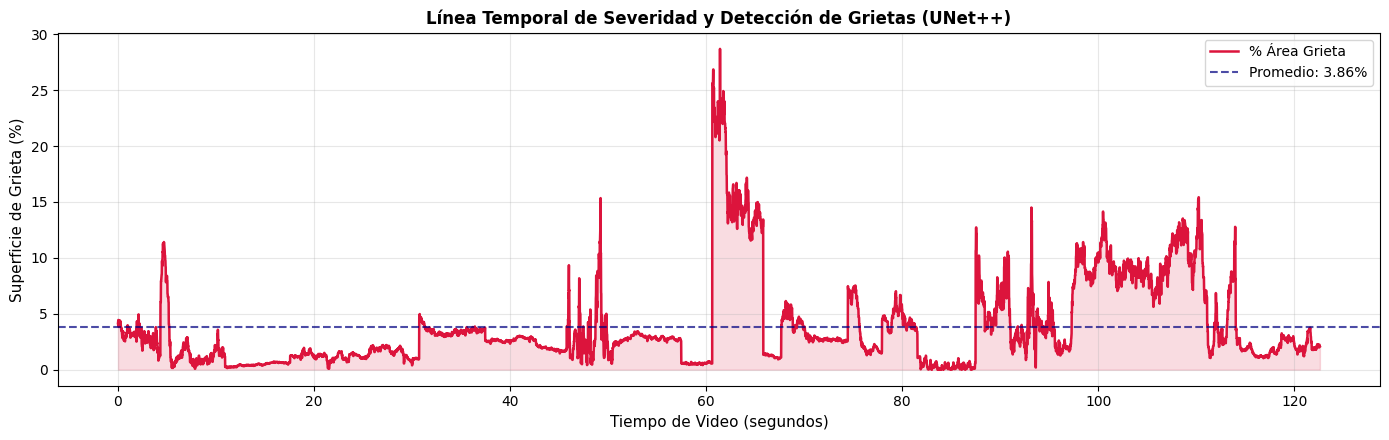

In [8]:
# ==============================================================================
# 6. ANÁLISIS ESTADÍSTICO Y TIMELINE DE DAÑO / SEVERIDAD
# ==============================================================================

if len(timeline_stats['frame_idx']) > 0:
    crack_pct_arr = np.array(timeline_stats['crack_area_pct'])
    frames_with_crack = sum(timeline_stats['has_crack'])
    total_f = len(crack_pct_arr)

    print("--- Estadísticas de Defectos en el Video ---")
    print(f"Frames con grieta detectada : {frames_with_crack}/{total_f} ({frames_with_crack/total_f*100:.1f}%)")
    print(f"Porcentaje de área promedio : {crack_pct_arr.mean():.3f}%")
    print(f"Porcentaje de área máximo   : {crack_pct_arr.max():.3f}% (Frame #{timeline_stats['frame_idx'][int(crack_pct_arr.argmax())]})")

    # Gráfico de línea temporal
    plt.figure(figsize=(14, 4.5))
    plt.plot(timeline_stats['time_sec'], timeline_stats['crack_area_pct'], color='crimson', lw=1.8, label='% Área Grieta')
    plt.axhline(y=crack_pct_arr.mean(), color='navy', linestyle='--', alpha=0.7, label=f'Promedio: {crack_pct_arr.mean():.2f}%')
    plt.fill_between(timeline_stats['time_sec'], timeline_stats['crack_area_pct'], color='crimson', alpha=0.15)

    plt.xlabel('Tiempo de Video (segundos)', fontsize=11)
    plt.ylabel('Superficie de Grieta (%)', fontsize=11)
    plt.title("Línea Temporal de Severidad y Detección de Grietas (UNet++)", fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


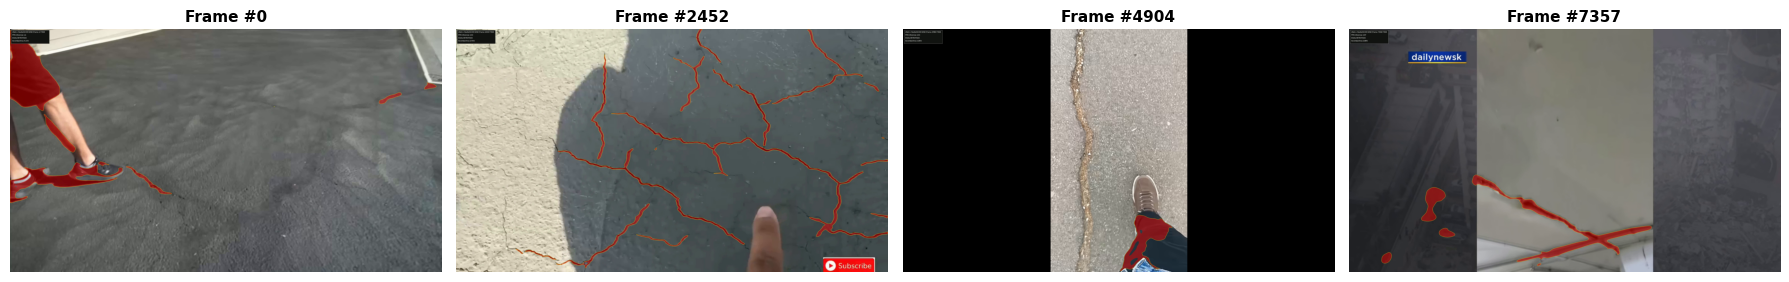

In [9]:
# ==============================================================================
# 7. VISUALIZACIÓN DE KEYFRAMES Y REPRODUCCIÓN EN NOTEBOOK / COLAB
# ==============================================================================

def sample_video_keyframes(video_path, num_samples=4):
    """
    Extrae y visualiza `num_samples` cuadros equidistantes del video resultante.
    """
    cap_out = cv2.VideoCapture(video_path)
    if not cap_out.isOpened():
        print(f"No se pudo abrir el video para extraer keyframes: {video_path}")
        return

    n_frames = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, max(0, n_frames - 1), num_samples, dtype=int)

    fig, axes = plt.subplots(1, num_samples, figsize=(4.5 * num_samples, 4))
    if num_samples == 1:
        axes = [axes]

    for i, f_idx in enumerate(indices):
        cap_out.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
        ret, frame = cap_out.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            axes[i].imshow(frame_rgb)
            axes[i].set_title(f"Frame #{f_idx}", fontsize=11, fontweight='bold')
        axes[i].axis('off')

    cap_out.release()
    plt.tight_layout()
    plt.show()

# Visualizar 4 cuadros de muestra del video generado
sample_video_keyframes(video_out_resolved, num_samples=4)

# ─── Reproductor de Video Integrado (Para Colab) ──────────────────────────────
def play_video_inline(video_path, width=720):
    """
    Reproduce el video directamente dentro de la celda de Colab / Jupyter si está en formato compatible.
    """
    from IPython.display import HTML
    from base64 import b64encode

    if not os.path.exists(video_path):
        print(f"Archivo no encontrado: {video_path}")
        return

    # Si el archivo es menor a 50MB, se codifica en base64 para reproducción inmediata
    size_mb = os.path.getsize(video_path) / (1024 * 1024)
    if size_mb <= 50:
        with open(video_path, 'rb') as f:
            mp4_data = f.read()
        data_url = "data:video/mp4;base64," + b64encode(mp4_data).decode()
        return HTML(f"""
        <video width="{width}" controls style="border-radius: 8px; box-shadow: 0 4px 12px rgba(0,0,0,0.15);">
            <source src="{data_url}" type="video/mp4">
            Tu navegador no soporta reproducción HTML5 directa.
        </video>
        """)
    else:
        print(f"El video pesa {size_mb:.1f} MB (demasiado grande para embed base64). Descárgalo o reprodúcelo localmente.")

# Descomentar para reproducir en Colab:
# play_video_inline(video_out_resolved)
